# W01 Mon — Setup and Orientation
## IIT414W · Unit I · Week 1 · Mon March 2, 2026

**Learning goals for this session:**
- Verify Python, conda/pip, Jupyter, and Git are correctly installed.
- Clone the course repo and run a reproducibility check.
- Understand the vibe-coder vs. agentic-engineer spectrum.
- Make a F1 winner prediction (intuition-based, no model) and document it.

**Before you start:** Confirm your environment is created from `environment.yml` or `requirements.txt` and that Git is available in your terminal.



In [1]:
# ── Reproducibility Header ────────────────────────────────────────────
# Every notebook in IIT414W starts here. Do not skip this block.

import sys, random
import numpy as np
import warnings

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

# Environment check
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')


Python  : 3.11.2
NumPy   : 2.4.3
Seed    : 414


In [2]:
# ── Dependency Guard ───────────────────────────────────────────────
# Ensures all required packages are installed in the active kernel.
# Safe to re-run: pip will skip already-installed packages.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# ── Library Imports ───────────────────────────────────────────────
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plotting
import fastf1                    # Formula 1 data access

print(f'fastf1  : {fastf1.__version__}')
print(f'pandas  : {pd.__version__}')

All required packages already installed ✓
fastf1  : 3.8.1
pandas  : 2.3.3


## 1. Environment Verification

**The idea.** We verify that the full local toolchain works before any analysis.

**In F1 terms.** A team validates telemetry feeds before strategy simulation.

> **Why it matters:** Setup problems masquerade as modeling mistakes if not checked first.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > How will we prove this machine can reproduce course notebooks from scratch?

2. **What does success look like? How will we know if the result is good?**
   > In my personal machine, since i use a linux distribution, i can use the requirements to install the libraries from pip in the enviroment. Also the code above this verify the instalation of modules with the python kernel that notebook is using so if a library is missing it will warn.

   > The success in this case looks like the correct execution of the cells.

3. **What could go wrong? Name one failure mode.**
   > that the version of python don't have support for the libraries.


In [3]:
required = ['numpy', 'pandas', 'sklearn', 'matplotlib', 'seaborn', 'fastf1']
rows = []
for pkg in required:
    mod = importlib.import_module(pkg)
    rows.append((pkg, getattr(mod, '__version__', 'n/a')))

print(pd.DataFrame(rows, columns=['package', 'version']).to_string(index=False))
print(f'Working directory: {os.getcwd()}')

# FastF1 cache — auto-create if missing
cache_path = os.path.join(os.path.dirname(os.getcwd()), '..', 'data', 'fastf1_cache')
cache_path = os.path.abspath(cache_path)
os.makedirs(cache_path, exist_ok=True)
fastf1.Cache.enable_cache(cache_path)
print(f'FastF1 cache enabled: {cache_path}')

print(subprocess.run(['git', '--version'], capture_output=True, text=True, check=False).stdout.strip())
log = subprocess.run(['git', 'log', '--oneline', '-5'], capture_output=True, text=True, check=False)
print('Recent commits:')
print(log.stdout.strip() if log.returncode == 0 else 'No commit history available in this folder.')

   package version
     numpy   2.4.3
    pandas   2.3.3
   sklearn   1.8.0
matplotlib  3.10.8
   seaborn  0.13.2
    fastf1   3.8.1
Working directory: /home/lucas/Universidad/WorkshopAI/iit414w-lab00-baltilucas
FastF1 cache enabled: /home/lucas/Universidad/data/fastf1_cache
git version 2.39.5
Recent commits:
49f123c Advance in data check
bc8e6f2 Change of gitignore
f48f172 Base Setup
85b8ea2 Initial commit


In [4]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Run one additional system check and explain why it supports reproducibility.
# Expected output: A short printout plus one risk note.
# Hint: You can check `sys.executable`, platform info, or free disk space.

import platform
import shutil
import locale

print('── OS & Architecture Verification ──────────────────────────────')

# Operating System and Release
print(f'OS Type        : {platform.system()}')
print(f'OS Release     : {platform.release()}')
print(f'OS Version     : {platform.version()}')


# Architecture (32-bit vs 64-bit)
print(f'Architecture   : {platform.architecture()[0]}')

# Free Disk Space
disk_usage = shutil.disk_usage('/')
print(f'\nFree Disk Space: {disk_usage.free / (1024**3):.1f} GB (on root partition)')
if disk_usage.free / (1024**3) < 5:
    print('⚠️  WARNING: Less than 5 GB free — FastF1 cache or data downloads may fail!')

# System Locale and Encoding
lang_code = locale.getlocale()[0]
encoding = locale.getpreferredencoding()
print(f'\nLocale         : {lang_code}')
print(f'Encoding       : {encoding}')


── OS & Architecture Verification ──────────────────────────────
OS Type        : Linux
OS Release     : 6.1.0-43-amd64
OS Version     : #1 SMP PREEMPT_DYNAMIC Debian 6.1.162-1 (2026-02-08)
Architecture   : 64bit

Free Disk Space: 91.0 GB (on root partition)

Locale         : es_CL
Encoding       : UTF-8


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

2. **Where could this technique fail or mislead you?**

3. **How would you explain this to a non-technical teammate?**


## 2. The Vibe Coder vs. Agentic Engineer

**The idea.** Agentic workflows require explicit decisions, checks, and evidence.

**In F1 terms.** Race engineers never trust a single number without validating context and assumptions.

> **Why it matters:** Decision quality, not code volume, is what we grade in this course.


### Spectrum Examples — Code Snippets

**Example 1 — AI suggests a train/test split:**

Vibe Coder:
```python
# AI says: just use train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# "Looks fine!" → ships it
```

Agentic Engineer:
```python
# Wait — is this temporal data? Random split could leak future info.
# Check: are there date columns? Is order meaningful?
print(df['year'].unique())  # 2019, 2020, 2021, 2022, 2023
# → Random split mixes years. Must split by time, not randomly.
```

**Example 2 — Model accuracy is 92%:**

Vibe Coder:
```python
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # 0.92
# "Great score!" → done
```

Agentic Engineer:
```python
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # 0.92
print(f"Majority baseline: {y_test.mean():.2f}")          # 0.90
# → Only 2% above always-predicting-majority. Basically useless.
```

**Example 3 — AI generates a feature engineering function:**

Vibe Coder:
```python
# Copies AI output directly into pipeline → no validation
def engineer_features(df):
    df['avg_position'] = df.groupby('driver')['position'].transform('mean')
    return df  # Uses future races to compute mean → leakage!
```

Agentic Engineer:
```python
# Before using: Does this use future information?
# 'mean' over ALL rows includes future races → target leakage!
# Fix: use expanding mean up to current race only
df['avg_position'] = df.groupby('driver')['position'].transform(
    lambda x: x.shift(1).expanding().mean()
)
```

| Scenario | Vibe Coder | Agentic Engineer |
|---|---|---|
| AI suggests code | Copies and runs | Tests assumptions and edge cases |
| Plot looks clean | Accepts narrative | Verifies labels, units, and sampling |
| Metric improves | Declares success | Checks leakage and baseline comparisons |

### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > Which one of your current coding habits is most likely to create silent errors?

2. **What does success look like? How will we know if the result is good?**
   > Identify some habits and make a retrospective of failures generated by them.

3. **What could go wrong? Name one failure mode.**
   > don't find because of excesive "vibe coding" or poorly selfknowledge.


In [5]:
self_check = pd.DataFrame(
    {
        'statement': [
            'I define success metrics before coding',
            'I verify train/val/test leakage explicitly',
            'I validate AI-generated code before reuse',
            'I document failed attempts',
            'I justify every modeling decision in writing',
        ],
        'score_1_to_5': [None, None, None, None, None],
    }
)
print(self_check.to_string(index=False))


                                   statement score_1_to_5
      I define success metrics before coding         None
  I verify train/val/test leakage explicitly         None
   I validate AI-generated code before reuse         None
                  I document failed attempts         None
I justify every modeling decision in writing         None


In [6]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Fill the checklist and write one concrete action to improve your lowest-scoring item.
# Expected output: A completed table and one action sentence.
# Hint: Honest scoring is more useful than optimistic scoring.

# TODO: Write your code here
self_check = pd.DataFrame(
    {
        'statement': [
            'I define success metrics before coding',
            'I verify train/val/test leakage explicitly',
            'I validate AI-generated code before reuse',
            'I document failed attempts',
            'I justify every modeling decision in writing',
        ],
        'score_1_to_5': [2, 5, 4, 2, 3],
    }
)


print(self_check.to_string(index=False))



                                   statement  score_1_to_5
      I define success metrics before coding             2
  I verify train/val/test leakage explicitly             5
   I validate AI-generated code before reuse             4
                  I document failed attempts             2
I justify every modeling decision in writing             3


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

2. **Where could this technique fail or mislead you?**

3. **How would you explain this to a non-technical teammate?**


## 3. Your First F1 Data Pull

**The idea.** We pull real FastF1 data and inspect lap-level structure before modeling.

**In F1 terms.** This is like opening timing screens before deciding race strategy.

> **Why it matters:** Early data literacy prevents poor feature assumptions later.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > What pattern do you expect to see in top-driver qualifying lap distributions?

2. **What does success look like? How will we know if the result is good?**
   > Find a pattern of velocity or time that is consistent in top-drivers, with improvements but consistently.

3. **What could go wrong? Name one failure mode.**
   > Lack of data, wrong implementation or use of incorrect data at each axis, showing something diferent than we expect.


core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '55', '27', '1', '10', '63', '14', '77', '11', '22', '30', '18', '16', '20', '23', '24', '44', '43', '61']


First 5 laps for VER:
Driver  LapNumber                LapTime Compound
   VER        2.0 0 days 00:01:23.516000     SOFT
   VER        3.0 0 days 00:01:56.133000     SOFT
   VER        5.0 0 days 00:01:23.612000     SOFT
   VER        6.0 0 days 00:01:35.987000     SOFT
   VER        8.0 0 days 00:01:22.998000     SOFT


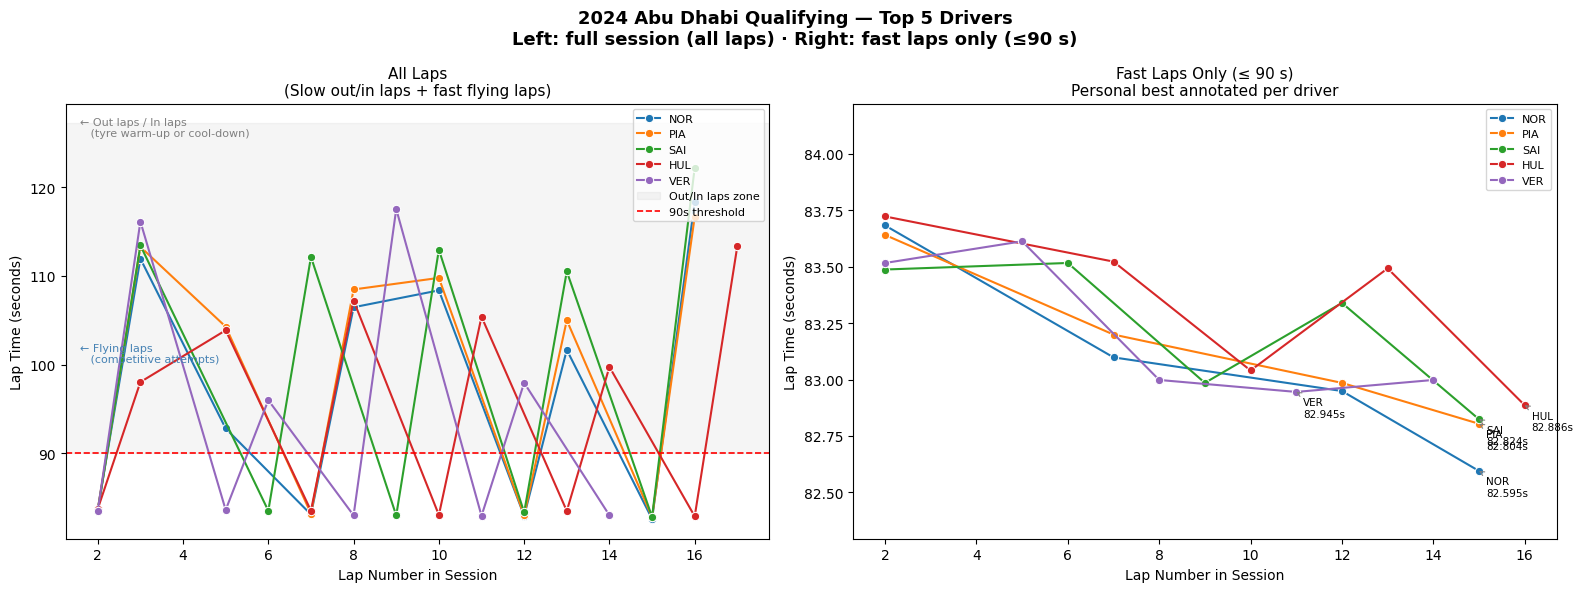


── Best Qualifying Lap per Driver (Top 5) ──
Driver  BestLapSec  GapToPole
   NOR      82.595      0.000
   PIA      82.804      0.209
   SAI      82.824      0.229
   HUL      82.886      0.291
   VER      82.945      0.350

💡 GapToPole: how many seconds behind the fastest qualifier each driver was.


In [7]:
# ── Load a Formula 1 Session ──────────────────────────────────────────────────
# fastf1.get_session() identifies a session by: year, event name (or round number), and session type.
# Session types: 'FP1', 'FP2', 'FP3' (Free Practice), 'Q' (Qualifying), 'R' (Race), 'S' (Sprint)
# 'Abu Dhabi' is the final race of the 2024 F1 season (Round 24).
session = fastf1.get_session(2024, 'Abu Dhabi', 'Q')

# session.load() fetches data from the FastF1 cache (or downloads it if not cached).
# We only need lap data here, so we disable the heavier telemetry/weather/messages
# to speed up loading. Set any of these to True if you need that data later.
#   laps=True      → lap-by-lap timing data (required for this analysis)
#   telemetry=False → car sensor data (speed, throttle, brake, gear) — not needed here
#   weather=False   → track temperature, wind, rain data — not needed here
#   messages=False  → race control messages (flags, penalties) — not needed here
session.load(laps=True, telemetry=False, weather=False, messages=False)

# ── Inspect VER (Max Verstappen) Lap Data ─────────────────────────────────────
# session.laps returns a special FastF1 DataFrame (Laps object) with all drivers.
# pick_drivers('VER') filters by driver abbreviation (3-letter code used in F1 broadcasts).
# Common abbreviations: NOR=Norris, VER=Verstappen, HAM=Hamilton, LEC=Leclerc, etc.
# LapTime is stored as a pandas Timedelta (days + HH:MM:SS.microseconds), not a float.
# dropna() removes laps where any selected column has missing data (e.g. aborted laps).
ver_laps = session.laps.pick_drivers('VER')[['Driver', 'LapNumber', 'LapTime', 'Compound']].dropna().head(5)
print('First 5 laps for VER:')
print(ver_laps.to_string(index=False))

# ── Get the Top 5 Qualifiers from Official Results ────────────────────────────
# session.results is a DataFrame with one row per driver, containing official timing.
# In qualifying, Position=1 is pole position (fastest overall Q3 time).
# We copy it to avoid accidentally modifying the original session data.
res = session.results.copy()

# Position can sometimes be stored as a string or mixed type — coerce to numeric.
# errors='coerce' turns any non-numeric value into NaN instead of raising an error.
res['Position'] = pd.to_numeric(res['Position'], errors='coerce')

# nsmallest(5, 'Position') picks the 5 rows with the lowest (best) position numbers.
# 'Abbreviation' gives us the 3-letter driver codes we need for lap filtering.
top5 = res.nsmallest(5, 'Position')['Abbreviation'].tolist()

# ── Build Plotting DataFrame for Top 5 Drivers ───────────────────────────────
# pick_drivers() also accepts a list of abbreviations — it returns all laps for those drivers.
# We keep only the columns we need for plotting: driver name, lap number, and lap time.
# .copy() ensures we work on a fresh DataFrame and not a view (avoids SettingWithCopyWarning).
plot_df = session.laps.pick_drivers(top5)[['Driver', 'LapNumber', 'LapTime']].dropna().copy()

# Convert Timedelta → float (seconds) for easy plotting on a numeric Y axis.
# dt.total_seconds() works on Timedelta columns; e.g. 0 days 00:01:22.595 → 82.595
plot_df['LapTimeSec'] = plot_df['LapTime'].dt.total_seconds()

# ── Separate fast laps from slow laps for cleaner visualization ───────────────
# In qualifying, drivers do:
#   - OUT LAPS  : slow laps to warm up tyres before a fast attempt  (> ~90s here)
#   - FLYING LAPS: the actual timed competitive laps               (<= ~90s here)
#   - IN LAPS   : slow laps returning to the pit box               (> ~90s here)
# We use 90 seconds as a threshold — anything faster is likely a competitive lap.
# Abu Dhabi circuit lap record is ~82s, so 90s gives us a comfortable margin.
# NOTE: This threshold is circuit-specific. For Monaco (~74s lap record) you'd use ~85s;
#       for Monza (~80s) you might use ~88s. Always check before applying.
FAST_LAP_THRESHOLD = 90  # seconds — adjust if session is at a shorter/longer circuit

fast_laps = plot_df[plot_df['LapTimeSec'] <= FAST_LAP_THRESHOLD]
slow_laps = plot_df[plot_df['LapTimeSec'] > FAST_LAP_THRESHOLD]

# ── Plot: Two panels side by side ─────────────────────────────────────────────
# plt.subplots(1, 2) creates a figure with 1 row and 2 columns of Axes (subplots).
# figsize=(16, 6) sets the figure width=16 inches, height=6 inches.
# axes[0] = left panel, axes[1] = right panel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    '2024 Abu Dhabi Qualifying — Top 5 Drivers\n'
    'Left: full session (all laps) · Right: fast laps only (≤90 s)',
    fontsize=13, fontweight='bold'
)

# ── LEFT PANEL: All laps — shows the full qualifying rhythm ───────────────────
# This panel helps students understand the structure of a qualifying session:
# Q1 (all 20 cars) → Q2 (top 15) → Q3 (top 10), each separated by slow in/out laps.
ax = axes[0]

# sns.lineplot with hue='Driver' automatically assigns a different color per driver
# and draws a line connecting their laps in order. marker='o' adds a dot at each lap.
sns.lineplot(data=plot_df, x='LapNumber', y='LapTimeSec',
             hue='Driver', marker='o', ax=ax)

# axhspan shades a horizontal band between two Y values across the full X range.
# This visually marks the "slow lap" region (out laps and in laps).
# alpha=0.08 makes the shading very transparent so lines remain readable.
ax.axhspan(FAST_LAP_THRESHOLD, plot_df['LapTimeSec'].max() + 5,
           alpha=0.08, color='gray', label='Out/In laps zone')

# axhline draws a horizontal reference line at y=FAST_LAP_THRESHOLD.
# linestyle='--' = dashed line; this is the boundary between slow and fast laps.
ax.axhline(FAST_LAP_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
           label=f'{FAST_LAP_THRESHOLD}s threshold')

ax.set_title('All Laps\n(Slow out/in laps + fast flying laps)', fontsize=11)
ax.set_xlabel('Lap Number in Session')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(fontsize=8, loc='upper right')

# ax.text with transform=ax.transAxes uses Axes-relative coordinates:
# (0, 0) = bottom-left corner, (1, 1) = top-right corner of the plot area.
# This keeps the annotation in the same relative position regardless of data range.
ax.text(0.02, 0.97, '← Out laps / In laps\n   (tyre warm-up or cool-down)',
        transform=ax.transAxes, fontsize=8, va='top', color='gray')
ax.text(0.02, 0.45, '← Flying laps\n   (competitive attempts)',
        transform=ax.transAxes, fontsize=8, va='top', color='steelblue')

# ── RIGHT PANEL: Fast laps only — reveals true pace comparison ────────────────
# Removing the out/in laps compresses the Y axis, making small differences
# between drivers (often < 0.5s in qualifying) clearly visible.
ax = axes[1]
sns.lineplot(data=fast_laps, x='LapNumber', y='LapTimeSec',
             hue='Driver', marker='o', ax=ax)

# Annotate the personal best lap for each driver.
# idxmin() returns the index label of the minimum value in the Series.
# ax.annotate() places a text label with an arrow pointing to the data point.
for driver in top5:
    driver_fast = fast_laps[fast_laps['Driver'] == driver]
    if driver_fast.empty:
        continue
    best_row = driver_fast.loc[driver_fast['LapTimeSec'].idxmin()]
    ax.annotate(
        f"{driver}\n{best_row['LapTimeSec']:.3f}s",  # .3f = 3 decimal places (millisecond precision)
        xy=(best_row['LapNumber'], best_row['LapTimeSec']),  # arrow tip: the actual data point
        xytext=(5, -18), textcoords='offset points',         # label offset in pixels from the tip
        fontsize=7.5, color='black',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

ax.set_title('Fast Laps Only (≤ 90 s)\nPersonal best annotated per driver', fontsize=11)
ax.set_xlabel('Lap Number in Session')
ax.set_ylabel('Lap Time (seconds)')
ax.legend(fontsize=8, loc='upper right')

# Tighten y-axis so small differences between drivers are visible.
# Without this, matplotlib auto-scales to include 0 on the Y axis,
# making a 0.3s gap between pole and P5 almost invisible.
y_min = fast_laps['LapTimeSec'].min()
y_max = fast_laps['LapTimeSec'].max()
ax.set_ylim(y_min - 0.3, y_max + 0.5)  # small padding around the actual data range

# tight_layout() automatically adjusts subplot spacing to prevent label overlap.
plt.tight_layout()
plt.show()

# ── Summary table: Best lap per driver ────────────────────────────────────────
# This table makes it easy to compare pole-lap pace without reading from the chart.
print('\n── Best Qualifying Lap per Driver (Top 5) ──')
best_laps = (
    fast_laps.groupby('Driver')['LapTimeSec']
    .min()                                          # best (minimum) lap time per driver
    .reset_index()                                  # turn the groupby result back into a flat DataFrame
    .rename(columns={'LapTimeSec': 'BestLapSec'})
    .sort_values('BestLapSec')                      # sort fastest → slowest (pole position first)
)
# GapToPole: difference between each driver's best lap and the pole-sitter's best lap.
# iloc[0] is the pole-sitter after sort_values, so subtracting gives 0.000 for pole.
best_laps['GapToPole'] = (best_laps['BestLapSec'] - best_laps['BestLapSec'].iloc[0]).round(3)
print(best_laps.to_string(index=False))
print('\n💡 GapToPole: how many seconds behind the fastest qualifier each driver was.')


── Lap Time Variance Comparison ──
Driver  StdDev_LapTimeSec  NumLaps
   SAI           0.310075        5
   VER           0.322211        5

Variance Summary: SAI shows more lap time consistency (lower std dev: 0.310s vs 0.322s), with a difference of 0.012s across their qualifying runs.


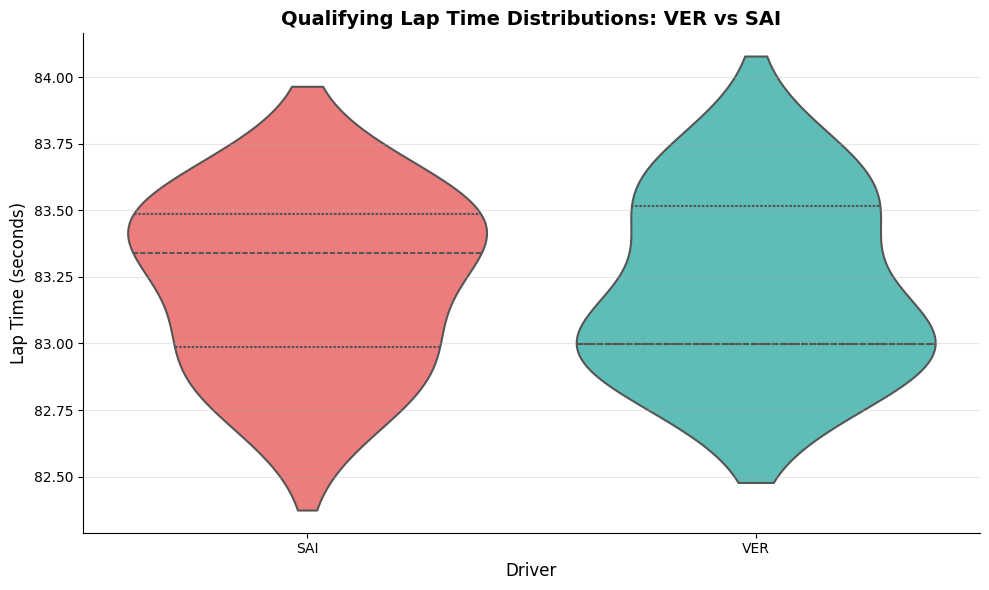

In [8]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Compare one additional driver against VER and summarize variance differences.
# Expected output: A table and one interpretation sentence.
# Hint: Use standard deviation of lap times in seconds.

# Pick an additional driver: the 5th place qualifier for contrast
additional_driver = top5[2]  # 5th in qualifying order

# Drivers to compare
drivers_to_compare = ['VER', additional_driver]

# Filter fast laps for these drivers
compare_df = fast_laps[fast_laps['Driver'].isin(drivers_to_compare)].copy()

# Compute standard deviation of lap times
std_table = (
    compare_df.groupby('Driver')['LapTimeSec']
    .agg(['std', 'count'])  # Also include count for context
    .reset_index()
    .rename(columns={'std': 'StdDev_LapTimeSec', 'count': 'NumLaps'})
)

print('── Lap Time Variance Comparison ──')
print(std_table.to_string(index=False))

# Interpretation sentence
ver_std = std_table.loc[std_table['Driver'] == 'VER', 'StdDev_LapTimeSec'].values[0]
add_std = std_table.loc[std_table['Driver'] == additional_driver, 'StdDev_LapTimeSec'].values[0]
variance_diff = abs(ver_std - add_std)
more_consistent = 'VER' if ver_std < add_std else additional_driver
print(f"\nVariance Summary: {more_consistent} shows more lap time consistency (lower std dev: {min(ver_std, add_std):.3f}s vs {max(ver_std, add_std):.3f}s), with a difference of {variance_diff:.3f}s across their qualifying runs.")

# Stylish graphic: Violin plot for lap time distributions
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=compare_df, 
    x='Driver', 
    y='LapTimeSec', 
    ax=ax, 
    palette=['#FF6B6B', '#4ECDC4'],  # Stylish colors: red for VER, teal for other
    inner='quartile',  # Show quartiles inside
    linewidth=1.5
)
ax.set_title('Qualifying Lap Time Distributions: VER vs ' + additional_driver, fontsize=14, fontweight='bold')
ax.set_xlabel('Driver', fontsize=12)
ax.set_ylabel('Lap Time (seconds)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
sns.despine()  # Remove top and right spines for cleaner look
plt.tight_layout()
plt.show()

### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

2. **Where could this technique fail or mislead you?**

3. **How would you explain this to a non-technical teammate?**


## 4. Prediction Card Activity

**The idea.** We capture a structured forecast before formal modeling begins.

**In F1 terms.** Teams commit assumptions before race outcomes are known, then revisit them.

> **Why it matters:** Documented assumptions reduce hindsight bias and improve learning loops.


### Prediction Card (fill this markdown cell)

1. **Who will win the 2025 Drivers' Championship?**
2. **What data would you use to support that prediction?**
3. **What could go wrong with your prediction?**


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > What assumptions are you making about the 2025 championship winner right now?

2. **What does success look like? How will we know if the result is good?**
   > [Student fills this in]

3. **What could go wrong? Name one failure mode.**
   > [Student fills this in]


In [9]:
prediction_card_template = {
    'predicted_2025_champion': '[fill in]',
    'evidence_plan': ['[feature/data source 1]', '[feature/data source 2]', '[feature/data source 3]'],
    'failure_modes': ['[risk 1]', '[risk 2]'],
}
print(prediction_card_template)


{'predicted_2025_champion': '[fill in]', 'evidence_plan': ['[feature/data source 1]', '[feature/data source 2]', '[feature/data source 3]'], 'failure_modes': ['[risk 1]', '[risk 2]']}


In [10]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Fill the prediction card in this notebook and keep it for Week 6 revisit.
# Expected output: A completed dictionary with explicit assumptions.
# Hint: Be specific about what could invalidate your prediction.

# TODO: Write your code here
prediction = [
    ("Predicted 2025 Champion", "Max Verstappen"),
    ("Evidence Plan", "Driver consistency metrics from 2023–2024 seasons"),
    ("Evidence Plan", "Qualifying vs race pace comparison using FastF1 data"),
    ("Failure Mode", " Regulation changes affecting drivers performance"),
    ("Failure Mode", "Unexpected crash in quelyfing ")
]

df = pd.DataFrame(prediction, columns=["Field", "Value"])
print(df.to_string(index=False))


                  Field                                                Value
Predicted 2025 Champion                                       Max Verstappen
          Evidence Plan    Driver consistency metrics from 2023–2024 seasons
          Evidence Plan Qualifying vs race pace comparison using FastF1 data
           Failure Mode     Regulation changes affecting drivers performance
           Failure Mode                       Unexpected crash in quelyfing 


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**

2. **Where could this technique fail or mislead you?**

3. **How would you explain this to a non-technical teammate?**


## 5. What Is Machine Learning? (Conceptual Anchor)

**The idea.** ML can be explained at intuitive, technical, and formal levels.

**In F1 terms.** A model is like a pit strategy simulator: useful under known conditions, fragile under shifts.

> **Why it matters:** Clear conceptual framing prevents wrong targets and wrong metrics.


### ML Taxonomy in F1

- **Supervised:** Predict Top-10 finish from pre-race features.
- **Unsupervised:** Cluster circuits by pace profile.
- **Reinforcement Learning:** Optimize pit timing via simulated reward.


### 🤔 Before you code: make a decision

Answer these questions in this cell before running any code below.

1. **What question are we trying to answer?**
   > Which ML paradigm best matches each F1 task: winner prediction, circuit clustering, pit strategy optimization?

2. **What does success look like? How will we know if the result is good?**
   > Finding a complete result that allow us identify problems and success situations.

3. **What could go wrong? Name one failure mode.**
   > Wrong implementation or consider features post-race because the unkwoledge of the sport


In [11]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=6, n_informative=4, random_state=RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print(f'Synthetic supervised demo accuracy: {accuracy_score(y_test, pred):.3f}')


Synthetic supervised demo accuracy: 0.960


In [12]:
# ── YOUR TURN ─────────────────────────────────────────────────────
# Task: Create a 3-row table: supervised, unsupervised, reinforcement learning with one F1 use case each.
# Expected output: A concise paradigm-to-use-case table.
# Hint: Include one risk if each paradigm is misapplied.

# TODO: Write your code here
data = {
    "Paradigm": [
        "Supervised Learning",
        "Unsupervised Learning",
        "Reinforcement Learning"
    ],
    "F1 Use Case": [
        "Predict race finishing position using q1,q2 laps data.",
        "Identify driver patterns.",
        "Optimize pit stop strategy."
    ],
    "RISK" : ["Data leakage if features include post-race variables.",
              "Data quality issues, like missing telemetry",
              "Wrong desing of reward producing unintended final strategy"
              ]
}


print(pd.DataFrame(data).to_string(index=False))

              Paradigm                                            F1 Use Case                                                       RISK
   Supervised Learning Predict race finishing position using q1,q2 laps data.      Data leakage if features include post-race variables.
 Unsupervised Learning                              Identify driver patterns.                Data quality issues, like missing telemetry
Reinforcement Learning                            Optimize pit stop strategy. Wrong desing of reward producing unintended final strategy


### 📝 Reflection

Answer the following in this cell (2-4 sentences each):

1. **What did you learn from this exercise that surprised you?**


The specificy of the implementation of AI use, like register every prompt and keep the outputs registered.

2. **Where could this technique fail or mislead you?**

I used to have a bad experience with AI models in c and C# implementations recently, so with some structures this could fail.

3. **How would you explain this to a non-technical teammate?**

I would talk him like a register of work, like an attendance register but of the workspace and the register of that.